# 03 – Forecasting Models (Day-Ahead Setup)

Dieses Notebook trainiert und bewertet Forecasting-Modelle für ein **Day-Ahead-Wind-Bidding-Setup**.

Wichtig: Es werden **keine Informationen aus der Zielstunde verwendet**, die einen Tag vorher nicht bekannt wären.  
Die gemessene `wind_speed` der Zielstunde wird daher **nicht** direkt als Feature genutzt.

Stattdessen werden verwendet:

- historische Produktions-Lags: 24h, 48h, 72h, 168h
- historische Windgeschwindigkeits-Lags: 24h, 48h, 72h, 168h
- Rolling Features, jeweils um mindestens 24h verschoben
- Kalenderfeatures: Stunde, Wochentag, Monat

Das Notebook macht **nur Forecasting**.  
Bidding, Newsvendor-Loss und Profit-Auswertung folgen erst in Notebook 04.


## 1. Imports und Pfade

In [39]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
# Projektwurzel setzen, damit src-Imports funktionieren
PROJECT_ROOT = Path.cwd().resolve()

# Falls das Notebook aus notebooks/ gestartet wird, eine Ebene nach oben gehen
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"

FORECAST_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: /Users/noahweis/wind_bidding_project
Data path: /Users/noahweis/wind_bidding_project/data/processed/final_dataset.csv


## 2. Modell-Imports aus `src.models`

Die Modell-Dateien sollten ein einheitliches Interface haben:

```python
model = train(X_train, y_train)
y_pred = predict(model, X_test)
metrics = evaluate(y_test, y_pred)
```

Bei Quantilmodellen:

```python
qr_models = train(X_train, y_train, quantiles=(0.25, 0.5, 0.75))
qr_preds = predict_all(qr_models, X_test)
```


In [40]:
from src.models import (
    linear_regression,
    random_forest,
    neural_net,
    quantile_regression,
    quantile_regression_forest,
    persistence_model,
    arima,
    elastic_net,
)


## 3. Daten laden

In [41]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
df.head()


(6600, 10)


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969


## 4. Zielvariable und Day-Ahead-Features erstellen

Für die spätere wirtschaftliche Bewertung in Notebook 04 wird die Zielvariable in **MWh** erzeugt.

Falls `power` in kW vorliegt und die Daten stündlich aggregiert sind:

\[
energy\_mwh = \frac{max(power\_kw, 0)}{1000}
\]

Negative Produktionswerte werden für den Einspeise-/Bidding-Kontext auf 0 begrenzt.


In [42]:
df_model = df.copy()

# Zielvariable für Bidding/Forecasting in MWh
df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000

# Kalenderfeatures sicherstellen
if "hour" not in df_model.columns:
    df_model["hour"] = df_model["timestamp"].dt.hour

if "dayofweek" not in df_model.columns:
    df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek

if "month" not in df_model.columns:
    df_model["month"] = df_model["timestamp"].dt.month

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["dow_sin"] = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

# Day-Ahead-Lags: mindestens 24h alt
for lag in [24, 48, 72, 168]:
    df_model[f"energy_lag_{lag}"] = df_model["energy_mwh"].shift(lag)

if "wind_speed" in df_model.columns:
    for lag in [24, 48, 72, 168]:
        df_model[f"wind_speed_lag_{lag}"] = df_model["wind_speed"].shift(lag)
else:
    warnings.warn("Spalte 'wind_speed' nicht gefunden. Wind-Lag-Features werden nicht erzeugt.")

# Rolling Features: mit shift(24), damit keine Zielstundeninformation enthalten ist
df_model["energy_roll_mean_24"] = df_model["energy_mwh"].shift(24).rolling(24).mean()
df_model["energy_roll_std_24"] = df_model["energy_mwh"].shift(24).rolling(24).std()
df_model["energy_roll_mean_168"] = df_model["energy_mwh"].shift(24).rolling(168).mean()

if "wind_speed" in df_model.columns:
    df_model["wind_roll_mean_24"] = df_model["wind_speed"].shift(24).rolling(24).mean()
    df_model["wind_roll_std_24"] = df_model["wind_speed"].shift(24).rolling(24).std()
    df_model["wind_roll_mean_168"] = df_model["wind_speed"].shift(24).rolling(168).mean()

df_model.head()


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,...,wind_speed_lag_24,wind_speed_lag_48,wind_speed_lag_72,wind_speed_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set definieren

Hier werden nur Features aufgenommen, die im Day-Ahead-Setup verfügbar wären.

**Nicht erlaubt:** `wind_speed` der Zielstunde direkt.  
**Erlaubt:** `wind_speed_lag_24`, `energy_lag_24`, Rolling Features mit `shift(24)`, Kalenderfeatures.


In [43]:
BASE_FEATURES = [
    "energy_lag_24",
    "energy_lag_48",
    "energy_lag_72",
    "energy_lag_168",
    "energy_roll_mean_24",
    "energy_roll_std_24",
    "energy_roll_mean_168",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month",
]

WIND_LAG_FEATURES = [
    "wind_speed_lag_24",
    "wind_speed_lag_48",
    "wind_speed_lag_72",
    "wind_speed_lag_168",
    "wind_roll_mean_24",
    "wind_roll_std_24",
    "wind_roll_mean_168",
]

FEATURES_DAY_AHEAD = BASE_FEATURES + [
    col for col in WIND_LAG_FEATURES if col in df_model.columns
]

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Features:", FEATURES_DAY_AHEAD)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


Features: ['energy_lag_24', 'energy_lag_48', 'energy_lag_72', 'energy_lag_168', 'energy_roll_mean_24', 'energy_roll_std_24', 'energy_roll_mean_168', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month', 'wind_speed_lag_24', 'wind_speed_lag_48', 'wind_speed_lag_72', 'wind_speed_lag_168', 'wind_roll_mean_24', 'wind_roll_std_24', 'wind_roll_mean_168']
X shape: (6409, 19)
y shape: (6409,)


,energy_lag_24,energy_lag_48,energy_lag_72,energy_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,hour_sin,hour_cos,dow_sin,dow_cos,month,wind_speed_lag_24,wind_speed_lag_48,wind_speed_lag_72,wind_speed_lag_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168
0,0.093500,0.000000,0.000000,0.311500,0.072257,0.154379,0.015471,5.000000e-01,-0.866025,-0.433884,-0.900969,4,5.150000,4.833333,2.216667,8.800000,5.714583,1.104419,3.511607
1,0.318000,0.000000,0.000000,0.298667,0.085507,0.161395,0.017364,2.588190e-01,-0.965926,-0.433884,-0.900969,4,5.000000,5.800000,3.400000,6.200000,5.681250,1.113762,3.526091
2,1.570167,0.000000,0.007500,0.000000,0.150931,0.342198,0.026710,1.224647e-16,-1.000000,-0.433884,-0.900969,4,8.400000,3.433333,4.066667,6.500000,5.888194,1.139057,3.554563
3,0.177167,0.109667,0.001833,0.000000,0.153743,0.342121,0.027582,-2.588190e-01,-0.965926,-0.433884,-0.900969,4,5.666667,6.050000,3.350000,6.416667,5.872222,1.139377,3.567262
4,0.000000,0.481333,0.000000,0.000000,0.133687,0.336139,0.026571,-5.000000e-01,-0.866025,-0.433884,-0.900969,4,4.766667,6.416667,5.200000,4.666667,5.803472,1.154774,3.567163


## 6. Zeitlicher Train-Test-Split

Für Zeitreihen wird **nicht zufällig geshuffelt**.  
Die ersten 80 % werden als Training genutzt, die letzten 20 % als Testzeitraum.


In [44]:
TEST_SIZE = 0.2
split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_index = df_model.loc[X_test.index, ["timestamp"]].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_index["timestamp"].min(), "bis", test_index["timestamp"].max())


Train: (5127, 19) (5127,)
Test: (1282, 19) (1282,)
Test period: 2016-11-08 11:00:00 bis 2016-12-31 23:00:00


## 7. Forecast-Metriken

Hier nutzen wir einfache Punktprognosemetriken.  
Pinball Loss wird separat für Quantilmodelle berechnet.


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


## 8. Baselines: Persistence 24h und 168h

Für Day-Ahead ist `Persistence_24h` die faire Baseline:

\[
\hat{y}_t = y_{t-24}
\]

`Persistence_1h` wird hier bewusst nicht als Hauptbaseline genutzt, weil es für ein Day-Ahead-Gebot nicht realistisch ist.


In [46]:
y_pred_p24 = df_model.loc[X_test.index, "energy_lag_24"].to_numpy()
y_pred_p168 = df_model.loc[X_test.index, "energy_lag_168"].to_numpy()

metrics_rows = []

for name, pred in {
    "Persistence_24h": y_pred_p24,
    "Persistence_168h": y_pred_p168,
}.items():
    row = {"model": name}
    row.update(evaluate_point_forecast(y_test, pred))
    metrics_rows.append(row)

pd.DataFrame(metrics_rows)


,model,MAE,RMSE,R2
0,Persistence_24h,0.603841,0.931794,-0.192071
1,Persistence_168h,0.775850,1.139235,-0.781923


## 9. Point Forecast Models trainieren

In [47]:
# Linear Regression
lr_model = linear_regression.train(X_train, y_train)
y_pred_lr = linear_regression.predict(lr_model, X_test)

# Elastic Net
en_model = elastic_net.train(X_train, y_train, alpha=0.1, l1_ratio=0.5)
y_pred_en = elastic_net.predict(en_model, X_test)

# Random Forest
rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
)
y_pred_rf = random_forest.predict(rf_model, X_test)

# Neural Network
nn_model = neural_net.train(
    X_train,
    y_train,
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
)
y_pred_nn = neural_net.predict(nn_model, X_test)

point_predictions = {
    "Linear_Regression": y_pred_lr,
    "Elastic_Net": y_pred_en,
    "Random_Forest": y_pred_rf,
    "Neural_Network": y_pred_nn,
}

for name, pred in point_predictions.items():
    row = {"model": name}
    row.update(evaluate_point_forecast(y_test, pred))
    metrics_rows.append(row)

pd.DataFrame(metrics_rows).sort_values("RMSE")


,model,MAE,RMSE,R2
3,Elastic_Net,0.577889,0.854585,-0.002705
2,Linear_Regression,0.595795,0.879006,-0.060832
4,Random_Forest,0.639567,0.903613,-0.121055
0,Persistence_24h,0.603841,0.931794,-0.192071
5,Neural_Network,0.701960,1.023470,-0.438179
1,Persistence_168h,0.775850,1.139235,-0.781923


## 10. ARIMA-Baseline

ARIMA wird als klassische Zeitreihen-Baseline ohne zusätzliche Wetterfeatures verwendet.  
Je nach Implementierung in `src.models.arima` kann diese Zelle angepasst werden.

Falls eure `arima.py` andere Funktionsnamen hat, bitte nur diesen Block anpassen, nicht die anderen Modelle.


In [48]:
try:
    # Variante A: falls arima.train / arima.predict vorhanden ist
    arima_model = arima.train(y_train)
    y_pred_arima = arima.predict(arima_model, steps=len(y_test))
except Exception as exc:
    print("ARIMA train/predict nicht kompatibel oder fehlgeschlagen:", exc)
    print("Fallback: Persistence_24h wird als Platzhalter für ARIMA verwendet.")
    arima_model = None
    y_pred_arima = y_pred_p24.copy()

row = {"model": "ARIMA"}
row.update(evaluate_point_forecast(y_test, y_pred_arima))
metrics_rows.append(row)

pd.DataFrame(metrics_rows).sort_values("RMSE")


  auto_arima gewählt: order=(1, 1, 2)


,model,MAE,RMSE,R2
3,Elastic_Net,0.577889,0.854585,-0.002705
6,ARIMA,0.609078,0.863626,-0.024032
2,Linear_Regression,0.595795,0.879006,-0.060832
4,Random_Forest,0.639567,0.903613,-0.121055
0,Persistence_24h,0.603841,0.931794,-0.192071
5,Neural_Network,0.701960,1.023470,-0.438179
1,Persistence_168h,0.775850,1.139235,-0.781923


## 11. Probabilistische Modelle: Quantile Regression und QRF

Für das Newsvendor-Bidding in Notebook 04 sind insbesondere die Quantile 0.25, 0.50 und 0.75 relevant.


In [49]:
QUANTILES = (0.25, 0.50, 0.75)

# Quantile Regression
qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
y_pred_qr_q50 = qr_preds["q50"].to_numpy()

# Quantile Regression Forest
qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()

for name, pred in {
    "Quantile_Regression_q50": y_pred_qr_q50,
    "QRF_q50": y_pred_qrf_q50,
}.items():
    row = {"model": name}
    row.update(evaluate_point_forecast(y_test, pred))
    metrics_rows.append(row)

forecast_metrics = pd.DataFrame(metrics_rows).drop_duplicates("model").sort_values("RMSE")
forecast_metrics


/Users/noahweis/wind_bidding_project/.venv-1/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/noahweis/wind_bidding_project/.venv-1/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/noahweis/wind_bidding_project/.venv-1/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/noahweis/wind_bidding_project/.venv-1/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/noahweis/wind_bidding_project/.venv-1/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has f

,model,MAE,RMSE,R2
3,Elastic_Net,0.577889,0.854585,-0.002705
6,ARIMA,0.609078,0.863626,-0.024032
2,Linear_Regression,0.595795,0.879006,-0.060832
4,Random_Forest,0.639567,0.903613,-0.121055
7,Quantile_Regression_q50,0.573253,0.930624,-0.189080
8,QRF_q50,0.610791,0.931644,-0.191688
0,Persistence_24h,0.603841,0.931794,-0.192071
5,Neural_Network,0.701960,1.023470,-0.438179
1,Persistence_168h,0.775850,1.139235,-0.781923


## 12. Pinball Loss für Quantilmodelle

In [50]:
pinball_rows = []

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]
pinball_metrics


,model,quantile,pinball_loss
0,Quantile_Regression,0.25,0.154686
1,Quantile_Regression,0.50,0.286626
2,Quantile_Regression,0.75,0.332303
3,QRF,0.25,0.173809
4,QRF,0.50,0.305395
5,QRF,0.75,0.345436


## 13. Predictions für Notebook 04 speichern

Die gespeicherte `predictions_day_ahead.csv` enthält die tatsächliche Produktion und alle Forecasts.

Diese Datei ist der Input für die spätere Bidding-Evaluation in Notebook 04.


In [51]:
predictions = pd.DataFrame({
    "timestamp": test_index["timestamp"].values,
    "y_true": y_test.to_numpy(),
    "persistence_24h": y_pred_p24,
    "persistence_168h": y_pred_p168,
    "arima": y_pred_arima,
    "linear_regression": y_pred_lr,
    "elastic_net": y_pred_en,
    "random_forest": y_pred_rf,
    "neural_network": y_pred_nn,
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
})

predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"
forecast_metrics_path = TABLES_DIR / "forecast_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)
forecast_metrics.to_csv(forecast_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", forecast_metrics_path)
print("Saved:", pinball_metrics_path)

predictions.head()


Saved: /Users/noahweis/wind_bidding_project/results/forecasts/predictions_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/forecasts/test_features_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/forecast_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/pinball_metrics_day_ahead.csv


,timestamp,y_true,persistence_24h,persistence_168h,arima,linear_regression,elastic_net,random_forest,neural_network,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,qrf_q25,qrf_q50,qrf_q75
0,2016-11-08 11:00:00,0.691000,0.204000,0.000000,0.415383,0.383088,0.384595,0.483573,0.390152,0.009333,0.097384,0.460804,0.221572,0.361917,0.639519
1,2016-11-08 12:00:00,0.891500,0.163167,0.000000,0.427135,0.396233,0.375880,0.455270,0.228743,0.009813,0.099309,0.474996,0.161312,0.333621,0.639882
2,2016-11-08 13:00:00,0.553667,0.328833,0.000000,0.436914,0.429249,0.391213,0.415285,0.278681,0.017462,0.127805,0.532744,0.161899,0.340731,0.633909
3,2016-11-08 14:00:00,0.387833,0.030500,0.000000,0.445050,0.390804,0.364578,0.528900,0.060106,0.010117,0.096559,0.456224,0.166383,0.420681,0.760979
4,2016-11-08 15:00:00,0.306667,0.037000,0.015167,0.451819,0.359301,0.370648,0.380900,0.035653,0.014794,0.101666,0.417144,0.125405,0.322190,0.590181


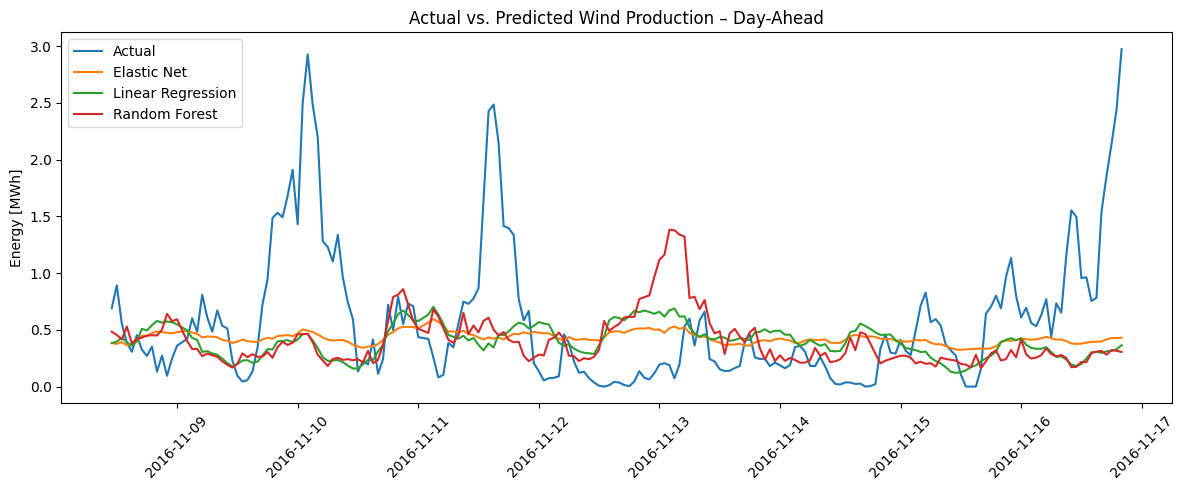

In [52]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["linear_regression"].iloc[:plot_window],
    label="Linear Regression",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Predicted Wind Production – Day-Ahead")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_predicted_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

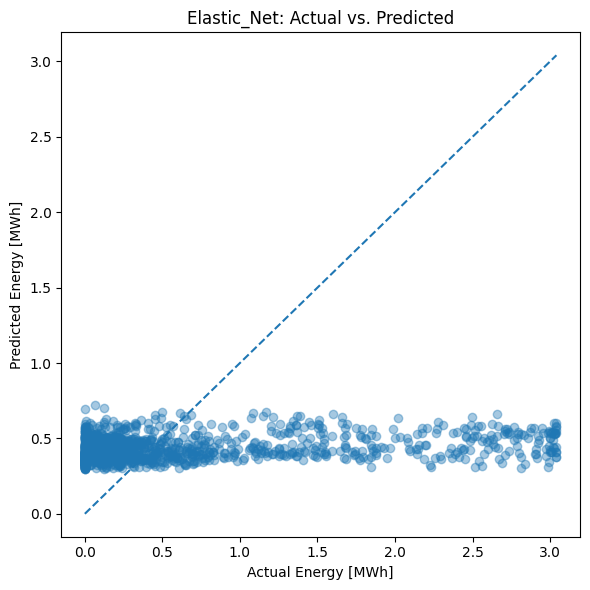

In [53]:
best_model = forecast_metrics.sort_values("RMSE").iloc[0]["model"]

model_column_map = {
    "Elastic_Net": "elastic_net",
    "ARIMA": "arima",
    "Linear_Regression": "linear_regression",
    "Random_Forest": "random_forest",
    "Quantile_Regression_q50": "quantile_regression_q50",
    "QRF_q50": "qrf_q50",
    "Persistence_24h": "persistence_24h",
    "Neural_Network": "neural_network",
    "Persistence_168h": "persistence_168h",
}

best_col = model_column_map[best_model]

plt.figure(figsize=(6, 6))

plt.scatter(
    predictions["y_true"],
    predictions[best_col],
    alpha=0.4,
)

max_value = max(
    predictions["y_true"].max(),
    predictions[best_col].max(),
)

plt.plot([0, max_value], [0, max_value], linestyle="--")
plt.xlabel("Actual Energy [MWh]")
plt.ylabel("Predicted Energy [MWh]")
plt.title(f"{best_model}: Actual vs. Predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_model_actual_vs_predicted_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Modelle speichern

Die gespeicherten Modelle können später für XAI oder Bidding geladen werden.


In [54]:
joblib.dump(lr_model, MODELS_DIR / "linear_regression_day_ahead.joblib")
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(nn_model, MODELS_DIR / "neural_network_day_ahead.joblib")
joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")

if arima_model is not None:
    try:
        joblib.dump(arima_model, MODELS_DIR / "arima_day_ahead.joblib")
    except Exception as exc:
        print("ARIMA konnte nicht gespeichert werden:", exc)

print("Modelle gespeichert in:", MODELS_DIR)


Modelle gespeichert in: /Users/noahweis/wind_bidding_project/results/models


## 15. Ergebnisüberblick

Diese Tabellen sind für das Paper relevant:

- `forecast_metrics_day_ahead.csv`
- `pinball_metrics_day_ahead.csv`

Das Bidding wird erst im nächsten Notebook bewertet.


In [55]:
forecast_metrics

,model,MAE,RMSE,R2
3,Elastic_Net,0.577889,0.854585,-0.002705
6,ARIMA,0.609078,0.863626,-0.024032
2,Linear_Regression,0.595795,0.879006,-0.060832
4,Random_Forest,0.639567,0.903613,-0.121055
7,Quantile_Regression_q50,0.573253,0.930624,-0.189080
8,QRF_q50,0.610791,0.931644,-0.191688
0,Persistence_24h,0.603841,0.931794,-0.192071
5,Neural_Network,0.701960,1.023470,-0.438179
1,Persistence_168h,0.775850,1.139235,-0.781923


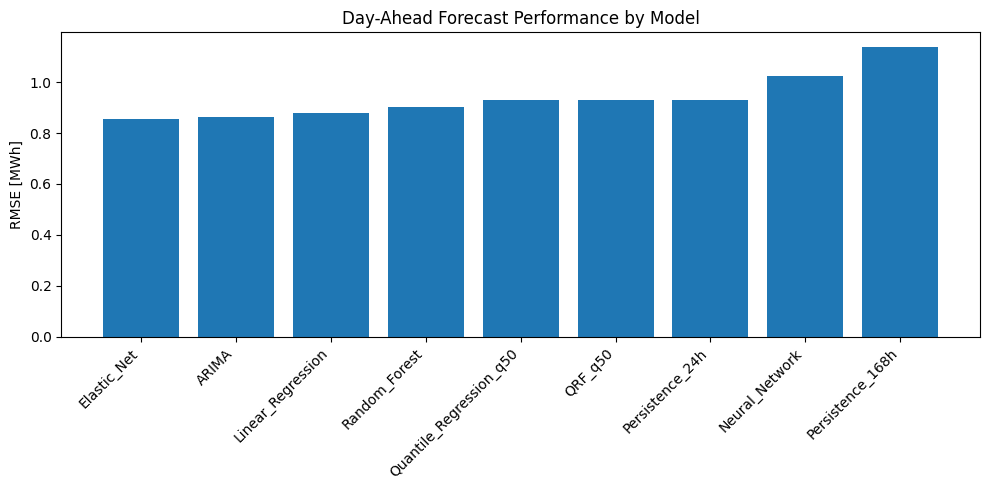

In [56]:
plot_df = forecast_metrics.sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Day-Ahead Forecast Performance by Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
pinball_metrics

,model,quantile,pinball_loss
0,Quantile_Regression,0.25,0.154686
1,Quantile_Regression,0.50,0.286626
2,Quantile_Regression,0.75,0.332303
3,QRF,0.25,0.173809
4,QRF,0.50,0.305395
5,QRF,0.75,0.345436


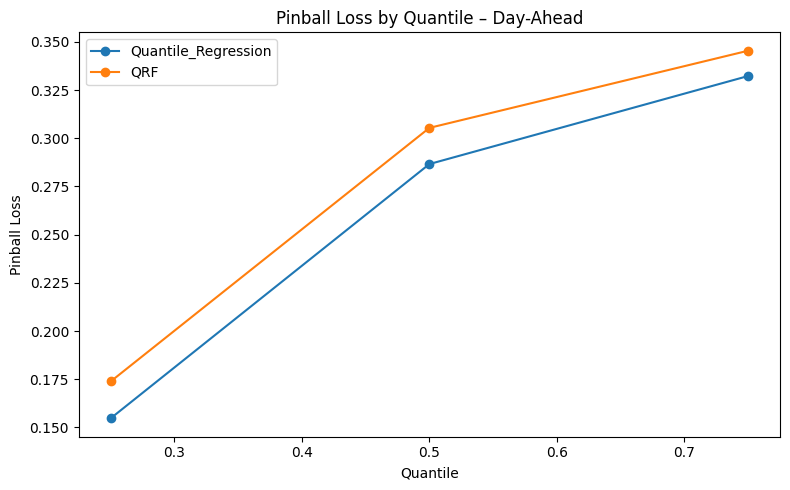

In [58]:
plt.figure(figsize=(8, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name]
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Pinball Loss by Quantile – Day-Ahead")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()